# 04 · Deployment & Prediction System — Seq2Seq LSTM (Jena Climate)

Notebook phục vụ **Slide 9: Deployment & Prediction System**.

## PHẦN 1 — Giới thiệu kiến trúc

Toàn bộ pipeline serving trong notebook này gọi **đúng code có sẵn của project**
(`src/serving/`, `api/main.py`, `scripts/export_bundle.py`) — không viết lại kiến trúc,
không tự dựng bundle giả.

**Flow:**

```
User
  |
  v
Streamlit (app/streamlit_app.py)
  |
  v
FastAPI (api/main.py — GET /health, GET /model-info, POST /predict)
  |
  v
Predictor (src/serving/predictor.py)
  |
  v
ModelBundle (src/serving/schemas.py, xây bằng src/serving/bundle.py)
  |
  v
Model (Seq2SeqLSTM, checkpoint thật đã training xong)
  |
  v
Forecast (72 giờ nhiệt độ, °C)
```

Notebook demo 2 tầng dưới cùng của flow này trực tiếp trong process (Predictor + ModelBundle,
Phần 3-4-6) và tầng API/Interface qua HTTP thật (Phần 5, khởi động `uvicorn` thật rồi gọi
`/health`, `/model-info`, `/predict`).


## PHẦN 2 — Import & Export Model Bundle

**Input:**
- `runs/seq2seq_lstm/seq2seq_lstm_20260917_055727_50fe09/` (run training thật, checkpoint +
  resolved_config.yaml + run_record.json)
- `artifacts/preprocessing/scaler.joblib`, `artifacts/preprocessing/feature_schema.json`
  (artifact preprocessing dùng chung, không phải per-run)

**Processing:** gọi `export_bundle_from_run()` trong `scripts/export_bundle.py` (module có
sẵn — **không tự tạo bundle bằng tay**). Hàm này gọi `src/serving/bundle.py::build_bundle()`
để copy checkpoint/scaler/schema/config/metadata vào một thư mục bundle bất biến, tính
SHA-256 từng file, rồi `verify_bundle()` + thử `load_bundle()` ngay để đảm bảo bundle dùng
được trước khi coi là thành công.

`build_bundle()` **từ chối ghi đè** một bundle đã tồn tại (thiết kế bất biến — immutable
release), nên nếu bundle đã được export từ trước, notebook sẽ bỏ qua bước export và dùng lại
bundle đó thay vì tạo bản trùng.

**Output:**
```
bundle/lstm/
├── model.pt
├── scaler.joblib
├── feature_schema.json
├── resolved_config.json
├── metadata.json
└── bundle_manifest.json
```


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False else Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import subprocess

import joblib
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src.utils.io import read_json
from scripts.export_bundle import export_bundle_from_run
from src.serving.bundle import load_bundle, verify_bundle
from src.serving.predictor import Predictor

RUN_DIR = PROJECT_ROOT / "runs" / "seq2seq_lstm" / "seq2seq_lstm_20260917_055727_50fe09"
BUNDLE_DIR = PROJECT_ROOT / "bundle" / "lstm"
run_record = read_json(RUN_DIR / "run_record.json")
RUN_ID = run_record["run_id"]

if BUNDLE_DIR.exists():
    print(f"Bundle đã tồn tại tại {BUNDLE_DIR.relative_to(PROJECT_ROOT)} "
          "(build_bundle() không ghi đè bundle đã export — thiết kế bất biến). "
          "Dùng lại bundle đã có, không export lại.")
else:
    schema = read_json(PROJECT_ROOT / "artifacts" / "preprocessing" / "feature_schema.json")
    model_cfg = run_record["resolved_config"]["model"]
    export_bundle_from_run(
        run_dir=RUN_DIR,
        output_dir=BUNDLE_DIR,
        model_class="src.models.seq2seq_lstm.Seq2SeqLSTM",
        model_name="seq2seq_lstm",
        model_version="1.0.0",
        run_id=RUN_ID,
        model_kwargs={
            "n_features": schema["n_features"],
            "target_feature_index": schema["target"]["index"],
            "hidden_size": model_cfg["hidden_size"],
            "num_layers": model_cfg["num_layers"],
            "dropout": model_cfg["dropout"],
            "horizon": model_cfg["horizon"],
        },
    )

for name in ["model.pt", "scaler.joblib", "feature_schema.json", "resolved_config.json",
             "metadata.json", "bundle_manifest.json"]:
    path = BUNDLE_DIR / name
    status = "OK" if path.is_file() else "Chưa có artifact"
    print(f"[{status}] bundle/lstm/{name}")


Bundle đã tồn tại tại bundle\lstm (build_bundle() không ghi đè bundle đã export — thiết kế bất biến). Dùng lại bundle đã có, không export lại.
[OK] bundle/lstm/model.pt
[OK] bundle/lstm/scaler.joblib
[OK] bundle/lstm/feature_schema.json
[OK] bundle/lstm/resolved_config.json
[OK] bundle/lstm/metadata.json
[OK] bundle/lstm/bundle_manifest.json


## PHẦN 3 — Load Bundle

**Input:** `bundle/lstm/` (Phần 2).

**Processing:** `verify_bundle()` kiểm checksum SHA-256 từng file + tính nhất quán
`run_id` giữa manifest/metadata; `load_bundle()` nạp `model` (state_dict thật,
`strict=True`), `scaler`, `feature_schema`, `resolved_config`, `metadata` thành một
`ModelBundle` — cả hai hàm đều lấy từ `src/serving/bundle.py`, không viết lại.

**Output:** `ModelBundle` sẵn sàng dùng cho `Predictor`; kiểm tra có đủ model / scaler /
schema / metadata.


In [2]:
manifest = verify_bundle(BUNDLE_DIR)
bundle = load_bundle(BUNDLE_DIR, device="cpu")

print(f"model:    {type(bundle.model).__name__}  (đã load_state_dict, eval mode: {not bundle.model.training})")
print(f"scaler:   {type(bundle.scaler).__name__}  (n_features_in_={bundle.scaler.n_features_in_})")
print(f"schema:   ordered_features={len(bundle.feature_schema['ordered_features'])} features, "
      f"target={bundle.feature_schema['target']['name']}")
print(f"metadata: run_id={bundle.metadata.get('run_id')}, status={bundle.metadata.get('status')}")
print(f"checksums ({len(bundle.checksums)} file): {list(bundle.checksums.keys())}")
print("\nBundle loaded successfully")


E:\Project_Deep\Project_DL_Weather_Forecasting\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


model:    Seq2SeqLSTM  (đã load_state_dict, eval mode: True)
scaler:   StandardScaler  (n_features_in_=18)
schema:   ordered_features=18 features, target=T (degC)
metadata: run_id=seq2seq_lstm_20260917_055727_50fe09, status=completed
checksums (5 file): ['model.pt', 'scaler.joblib', 'feature_schema.json', 'resolved_config.json', 'metadata.json']

Bundle loaded successfully


## PHẦN 4 — Test Predictor

**Input:** 168 giờ lịch sử thật, shape `[1,168,18]` — lấy từ payload demo thật
(`scripts/generate_demo_payload.py`, cửa sổ thật trích từ `data/raw/jena_climate_2009_2016.csv`
qua đúng pipeline preprocessing trước bước scaling, `provenance.synthetic=false`).

**Flow (đúng code thật trong `src/serving/predictor.py::Predictor.predict`):**
```
Validation (_validate_timestamps, _feature_matrix)
        |
        v
Scaling (bundle.scaler.transform)
        |
        v
Inference (model(x, y=None, teacher_forcing_ratio=0.0))
        |
        v
Inverse scaling (inverse_scale_target)
```

**Output:** 72 `PredictionRecord` (nhiệt độ °C).


In [3]:
PAYLOAD_DIR = PROJECT_ROOT / "artifacts" / "demo" / "payloads"
PAYLOAD_DIR.mkdir(parents=True, exist_ok=True)
DEMO_PAYLOAD_PATH = PAYLOAD_DIR / "demo_payload.json"

if not DEMO_PAYLOAD_PATH.is_file():
    subprocess.run(
        [sys.executable, "scripts/generate_demo_payload.py",
         "--output", str(DEMO_PAYLOAD_PATH), "--split", "validation"],
        cwd=str(PROJECT_ROOT), check=True,
    )

demo_payload = json.loads(DEMO_PAYLOAD_PATH.read_text(encoding="utf-8"))
assert demo_payload["provenance"]["synthetic"] is False, "Demo payload phải là dữ liệu thật"

n_timestamps = len(demo_payload["timestamps"])
n_features_payload = len(demo_payload["observations"][0])
print(f"Input shape thật: [1,{n_timestamps},{n_features_payload}]  (kỳ vọng [1,168,18])")

predictor = Predictor(bundle)
predictions = predictor.predict(demo_payload["observations"], demo_payload["timestamps"])

print(f"Số prediction trả về: {len(predictions)}  (kỳ vọng 72)")
print(f"Record đầu tiên: {predictions[0]}")
print(f"Record cuối cùng: {predictions[-1]}")

persistence_baseline = predictor.persistence_baseline(demo_payload["observations"])
print(f"\nPersistence baseline (72 giá trị, anchor lặp lại): {persistence_baseline[0]:.4f} °C")


Input shape thật: [1,168,18]  (kỳ vọng [1,168,18])


E:\Project_Deep\Project_DL_Weather_Forecasting\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Số prediction trả về: 72  (kỳ vọng 72)
Record đầu tiên: PredictionRecord(timestamp='2014-08-15T10:00:00', y_true=None, y_pred=17.10186830317502, model_name='seq2seq_lstm', model_version='1.0.0', split='inference', run_id='seq2seq_lstm_20260917_055727_50fe09', horizon=1, unit='degC')
Record cuối cùng: PredictionRecord(timestamp='2014-08-18T09:00:00', y_true=None, y_pred=17.033289540644347, model_name='seq2seq_lstm', model_version='1.0.0', split='inference', run_id='seq2seq_lstm_20260917_055727_50fe09', horizon=72, unit='degC')

Persistence baseline (72 giá trị, anchor lặp lại): 15.9233 °C


## PHẦN 5 — API Demo

**Input:** bundle thật (`bundle/lstm`), payload demo thật (Phần 4).

**Processing:** `scripts/smoke_test_api.py` (module có sẵn, viết cho đúng mục đích này) khởi
động `uvicorn api.main:app` thật với `JENA_MODEL_BUNDLE=bundle/lstm`, gọi tuần tự
`GET /health`, `GET /model-info`, `POST /predict` qua HTTP thật rồi tắt server — không mock,
không tự bịa response.

**Output:** `artifacts/demo/api_response.json`.


In [4]:
API_RESPONSE_PATH = PROJECT_ROOT / "artifacts" / "demo" / "api_response.json"

result = subprocess.run(
    [sys.executable, "scripts/smoke_test_api.py",
     "--bundle", str(BUNDLE_DIR),
     "--payload", str(DEMO_PAYLOAD_PATH),
     "--output", str(API_RESPONSE_PATH),
     "--port", "8322"],
    cwd=str(PROJECT_ROOT), capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
assert API_RESPONSE_PATH.is_file(), "Chưa có artifact: api_response.json"

api_response = json.loads(API_RESPONSE_PATH.read_text(encoding="utf-8"))
print(f"GET /health      -> {api_response['health']['status_code']}  {api_response['health']['body']}")
print(f"GET /model-info  -> {api_response['model_info']['status_code']}")
print(f"POST /predict    -> {api_response['predict']['status_code']}  "
      f"({len(api_response['predict']['body']['predictions'])} predictions, "
      f"latency={api_response['predict']['body']['latency_ms']:.1f} ms)")


Saved: E:\Project_Deep\Project_DL_Weather_Forecasting\artifacts\demo\api_response.json
/health -> 200
/model-info -> 200
/predict -> 200

GET /health      -> 200  {'status': 'ready'}
GET /model-info  -> 200
POST /predict    -> 200  (72 predictions, latency=269.6 ms)


## PHẦN 6 — Visualization Demo

**Input:** lịch sử 168h từ payload demo (Phần 4), 72 `PredictionRecord` từ `Predictor`
(Phần 4), `future_actual` thật đi kèm payload (vì payload lấy từ validation split đã biết
tương lai — không dùng cho model, chỉ để đối chiếu trực quan).

**Processing:** vẽ lịch sử + forecast bằng `matplotlib` (project chưa có sẵn hàm vẽ dạng
"lịch sử nối forecast" — `save_forecast_figure` trong `src/evaluation/visualization.py` vẽ
actual-vs-pred trên cùng một trục thời gian dự báo, không nối lịch sử phía trước, nên phần
này viết riêng, không thay thế hàm evaluation nào đã có).

**Output:** `artifacts/demo/deployment_forecast.png`.


Đã lưu: E:\Project_Deep\Project_DL_Weather_Forecasting\artifacts\demo\deployment_forecast.png


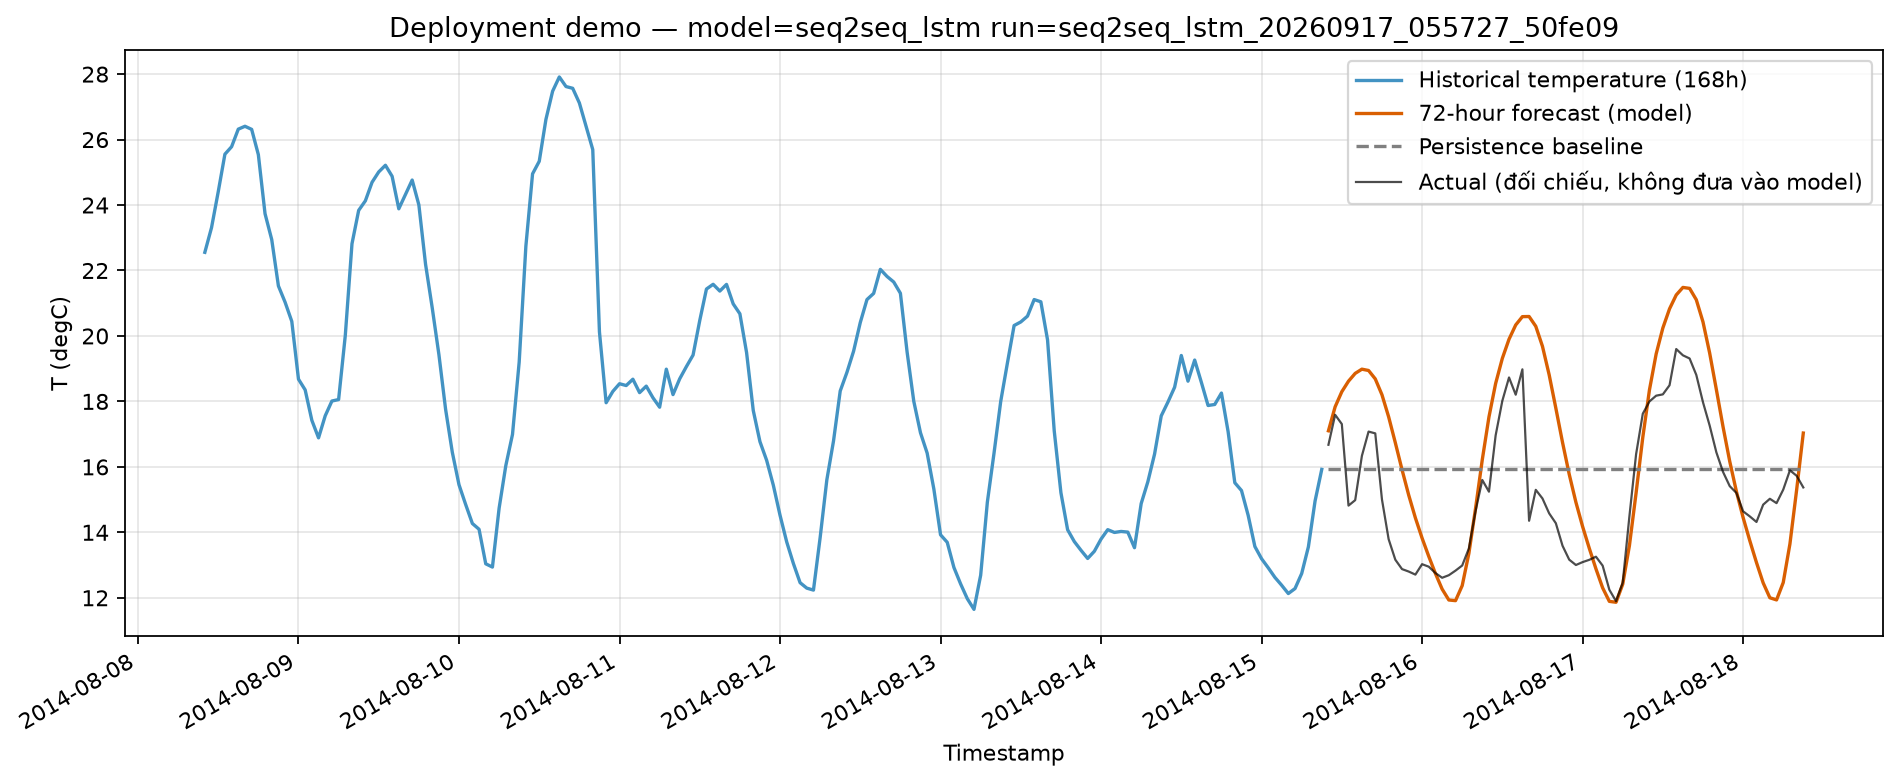


=== Checklist artifact cho Slide 9 ===
[OK] bundle\lstm\bundle_manifest.json
[OK] artifacts\demo\api_response.json
[OK] artifacts\demo\deployment_forecast.png


In [5]:
import pandas as pd

target_name = bundle.feature_schema["target"]["name"]
history_values = [obs[target_name] for obs in demo_payload["observations"]]
history_timestamps = pd.to_datetime(demo_payload["timestamps"])

forecast_timestamps = pd.to_datetime([record.timestamp for record in predictions])
forecast_values = [record.y_pred for record in predictions]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history_timestamps, history_values, label="Historical temperature (168h)", color="#4393c3")
ax.plot(forecast_timestamps, forecast_values, label="72-hour forecast (model)", color="#d95f02")
ax.plot(forecast_timestamps, persistence_baseline, label="Persistence baseline", color="gray", linestyle="--")
if "future_actual" in demo_payload:
    ax.plot(pd.to_datetime(demo_payload["future_timestamps"]), demo_payload["future_actual"],
            label="Actual (đối chiếu, không đưa vào model)", color="black", linewidth=1, alpha=0.7)
ax.set_xlabel("Timestamp")
ax.set_ylabel(f"{target_name}")
ax.set_title(f"Deployment demo — model={bundle.model_name} run={bundle.run_id}")
ax.legend()
ax.grid(alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()

DEMO_FIG_PATH = PROJECT_ROOT / "artifacts" / "demo" / "deployment_forecast.png"
DEMO_FIG_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(DEMO_FIG_PATH, dpi=160, bbox_inches="tight")
plt.close(fig)

print(f"Đã lưu: {DEMO_FIG_PATH}")
display(Image(filename=str(DEMO_FIG_PATH)))

print("\n=== Checklist artifact cho Slide 9 ===")
for path in [BUNDLE_DIR / "bundle_manifest.json", API_RESPONSE_PATH, DEMO_FIG_PATH]:
    status = "OK" if path.is_file() else "Chưa có artifact"
    print(f"[{status}] {path.relative_to(PROJECT_ROOT)}")
